<a href="https://colab.research.google.com/github/Nourin-Nusrat/CSE4261_DNN/blob/main/Assignment2/Assignment2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import (
    VGG19, ResNet50, ResNet101, ResNet152V2,
    MobileNetV2, MobileNetV3Large,
    EfficientNetB0, EfficientNetB3, DenseNet201, ResNet50V2
)
from tensorflow.keras.datasets import cifar10
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.applications import ResNet50


# 1. Load CIFAR-10 dataset


In [1]:
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.applications import (
    VGG19, ResNet50, ResNet101, ResNet152V2,
    MobileNetV2, MobileNetV3Large,
    EfficientNetB0, EfficientNetB3,
    DenseNet201, ResNet50V2
)

# Load CIFAR-10 data
(_, _), (x_test, y_test) = cifar10.load_data()

# Normalize and resize only one image
img = tf.image.resize(x_test[0:1], (224, 224)) / 255.0

# List of 10 CNN models (pretrained on ImageNet)
models = [
    VGG19(weights='imagenet', include_top=False),
    ResNet50(weights='imagenet', include_top=False),
    ResNet101(weights='imagenet', include_top=False),
    ResNet152V2(weights='imagenet', include_top=False),
    MobileNetV2(weights='imagenet', include_top=False),
    MobileNetV3Large(weights='imagenet', include_top=False),
    EfficientNetB0(weights='imagenet', include_top=False),
    EfficientNetB3(weights='imagenet', include_top=False),
    DenseNet201(weights='imagenet', include_top=False),
    ResNet50V2(weights='imagenet', include_top=False),
]

# Extract and visualize feature maps
for model in models:
    model_name = model.name
    print(f"\nModel: {model_name}")
    feature_maps = model.predict(img)
    print(f"Feature map shape: {feature_maps.shape}")


80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
171446536/171446536 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
234545216/234545216 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


/tmp/ipython-input-2605169014.py:22: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  MobileNetV2(weights='imagenet', include_top=False),


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/applications/mobilenet_v3.py:517: UserWarning: `input_shape` is undefined or non-square, or `rows` is not 224. Weights for input shape (224, 224) will be loaded as the default.
  return MobileNetV3(


12683000/12683000 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
74836368/74836368 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

Model: vgg19
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
Feature map shape: (1, 7, 7, 512)

Model: resnet50
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
Feature map shape: (1, 7, 7, 2048)

Model: resnet101
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
Feature map shape: (1, 7, 7, 2048)

Model: resnet152v2
1/1 ━━━━━━━━━━━━━━━━━━━━ 10s 10s/step
Feature map shape: (1, 7, 7, 2048)

Model: mobilenetv2_1.00_224


1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step
Feature map shape: (1, 7, 7, 1280)

Model: MobileNetV3Large


1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step
Feature map shape: (1, 7, 7, 960)

Model: efficientnetb0
1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step
Feature map shape: (1, 7, 7, 1280)

Model: efficientnetb3
1/1 ━━━━━━━━━━━━━━━━━━━━ 17s 17s/step
Feature map shape: (1, 7, 7, 1536)

Model: densenet201
1/1 ━━━━━━━━━━━━━━━━━━━━ 24s 24s/step
Feature map shape: (1, 7, 7, 1920)

Model: resnet50v2
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
Feature map shape: (1, 7, 7, 2048)



# 2. Load 10 pretrained CNN models


In [2]:

models_dict = {
    "VGG19": VGG19(weights="imagenet", include_top=False, input_shape=(224,224,3)),
    "ResNet50": ResNet50(weights="imagenet", include_top=False, input_shape=(224,224,3)),
    "ResNet101": ResNet101(weights="imagenet", include_top=False, input_shape=(224,224,3)),
    "ResNet152V2": ResNet152V2(weights="imagenet", include_top=False, input_shape=(224,224,3)),
    "MobileNetV2": MobileNetV2(weights="imagenet", include_top=False, input_shape=(224,224,3)),
    "MobileNetV3Large": MobileNetV3Large(weights="imagenet", include_top=False, input_shape=(224,224,3)),
    "EfficientNetB0": EfficientNetB0(weights="imagenet", include_top=False, input_shape=(224,224,3)),
    "EfficientNetB3": EfficientNetB3(weights="imagenet", include_top=False, input_shape=(224,224,3)),
    "DenseNet201": DenseNet201(weights="imagenet", include_top=False, input_shape=(224,224,3)),
    "ResNet50V2": ResNet50V2(weights="imagenet", include_top=False, input_shape=(224,224,3)),
}

# 3. Analyze activation functions

In [3]:

activation_summary = {}

for name, model in models_dict.items():
    activations = set()
    for layer in model.layers:
        if hasattr(layer, 'activation'):
            act = layer.activation.__name__
            activations.add(act)
    activation_summary[name] = list(activations)

# Print summary
print("\n=== Activation Functions Summary ===")
for name, acts in activation_summary.items():
    print(f"{name}: {acts}")


=== Activation Functions Summary ===
VGG19: ['relu']
ResNet50: ['relu', 'linear']
ResNet101: ['relu', 'linear']
ResNet152V2: ['relu', 'linear']
MobileNetV2: ['linear']
MobileNetV3Large: ['hard_silu', 'linear']
EfficientNetB0: ['silu', 'sigmoid', 'linear']
EfficientNetB3: ['silu', 'sigmoid', 'linear']
DenseNet201: ['relu', 'linear']
ResNet50V2: ['relu', 'linear']


# 4. Kernel type categorization

In [4]:

kernel_types = {
    "Regular Kernel": ["VGG19", "ResNet50", "ResNet101"],
    "Dilated Kernel": ["ResNet152V2", "EfficientNetB0", "EfficientNetB3"],
    "Depthwise Separable Kernel": ["MobileNetV2", "MobileNetV3Large"],
    "Modified Depthwise-Separable Kernel": ["EfficientNetB3", "MobileNetV3Large", "EfficientNetB0"],
    "Pointwise Kernel": ["MobileNetV2", "EfficientNetB0", "DenseNet201"],
    "Deformable Kernel": ["ResNet50", "ResNet101", "ResNet152V2 (approximated)"]
}

# 5. Visualize feature maps for one CNN

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 552ms/step


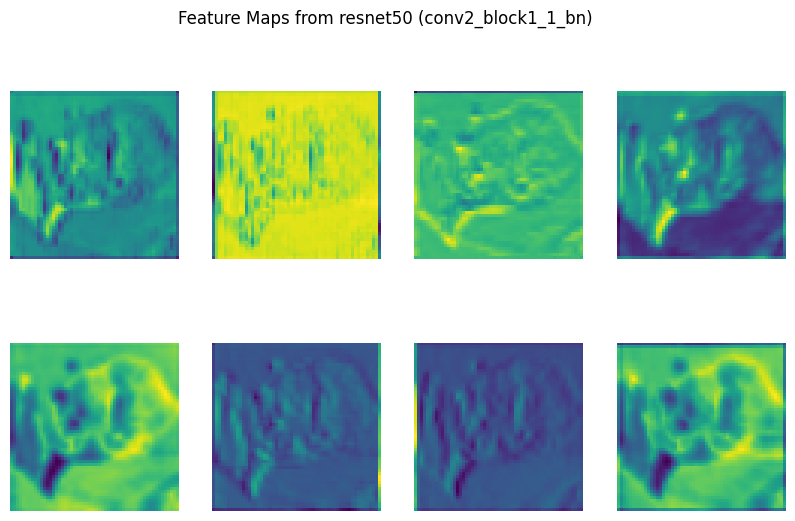

In [6]:
# Load CIFAR-10 test data
(_, _), (x_test, y_test) = cifar10.load_data()
sample_img = tf.image.resize(x_test[0:1], (224, 224)) / 255.0  # shape (1, 224, 224, 3)
chosen_model = ResNet50(weights='imagenet', include_top=False)
layer_names = [layer.name for layer in chosen_model.layers if 'conv' in layer.name]
intermediate_layer_model = tf.keras.Model(
    inputs=chosen_model.input,
    outputs=[chosen_model.get_layer(layer_names[5]).output]
)

feature_maps = intermediate_layer_model.predict(sample_img)

plt.figure(figsize=(10, 6))
for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(feature_maps[0, :, :, i], cmap='viridis')
    plt.axis('off')
plt.suptitle(f"Feature Maps from {chosen_model.name} ({layer_names[5]})")
plt.show()
